In [1]:
import os
from pathlib import Path

import pandas as pd

curr_dir = Path.cwd()
DATA_DIR = curr_dir.parent / "data"
OUTPUT_PATH = DATA_DIR / "geocode_final_scaled_2026q2.csv"

data_final = pd.read_csv(DATA_DIR / "geocode_final.csv")
rpi = pd.read_csv(DATA_DIR / "rpi-table.csv")

pd.set_option('display.max_columns', None)

C:\Users\zheng\AppData\Local\Temp\ipykernel_14924\2323675141.py:10: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  data_final = pd.read_csv(DATA_DIR / "geocode_final.csv")


## RPI index over time

C:\Users\zheng\AppData\Local\Temp\ipykernel_14924\2013430690.py:4: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  rpi_sorted["period"] = pd.PeriodIndex(


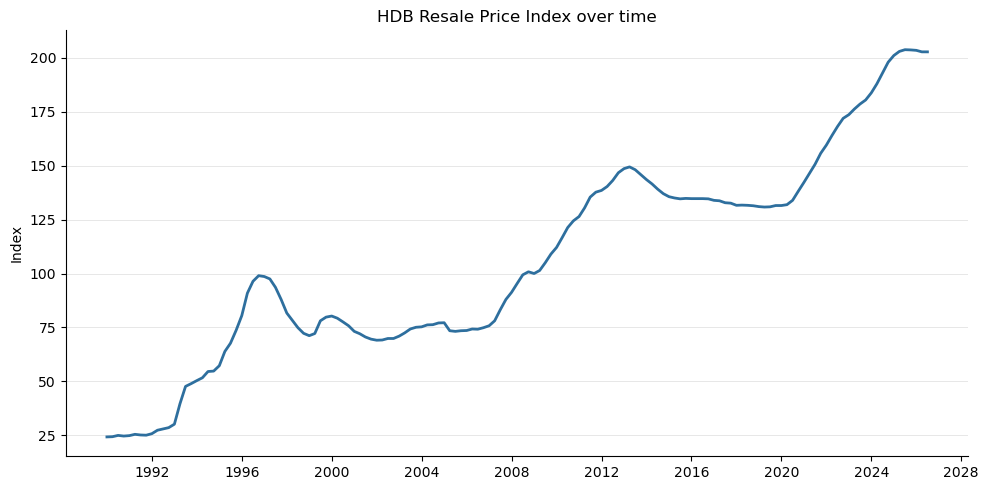

In [2]:
import matplotlib.pyplot as plt

rpi_sorted = rpi.sort_values(["Year", "Quarter"]).copy()
rpi_sorted["period"] = pd.PeriodIndex(
    year=rpi_sorted["Year"], quarter=rpi_sorted["Quarter"], freq="Q"
).to_timestamp()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rpi_sorted["period"], rpi_sorted["Index"], color="#2E6F9E", linewidth=2)

ax.set_title("HDB Resale Price Index over time")
ax.set_xlabel("")
ax.set_ylabel("Index")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#DDDDDD", linewidth=0.5)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

## Filter from 2023 Q1 



In [3]:
data_final["month"] = pd.to_datetime(data_final["month"])

mask = (data_final["month"] >= "2023-01-01")
data_2023on = data_final[mask].copy()
data_2023on.shape

(91753, 32)

## Map each transaction month to its RPI quarter

`geocode_final` has one row per transaction with `month` as `YYYY-MM-01`, while `rpi-table` is
quarterly (`Year`, `Quarter`, `Index`). Derive `Year`/`Quarter` from the transaction month so it can
be joined onto the RPI table.

In [4]:
data_2023on["Year"] = data_2023on["month"].dt.year
data_2023on["Quarter"] = data_2023on["month"].dt.quarter

data_2023on = data_2023on.merge(rpi, on=["Year", "Quarter"], how="left", validate="many_to_one")

# Every 2023+ transaction should find a matching RPI quarter (RPI runs through 2026 Q2)
assert data_2023on["Index"].notna().all(), "Some transactions did not match an RPI quarter"

In [5]:
data_2023on.head()

,month,town,flat_type,block,street_name,address,storey_range,floor_area_sqm,flat_model,lease_commence_date,flat_age_years,remaining_lease_years,resale_price,source_file,Unnamed: 0,onemap_searchval,onemap_blk_no,onemap_road_name,onemap_building,onemap_address,onemap_postal,onemap_x,onemap_y,latitude,longitude,Town,Region,Area (km2),Population (2025)[8],Population density (/km2),Subzones,town_cleaned,Year,Quarter,Index
0,2023-01-01,ANG MO KIO,3 ROOM,220,ANG MO KIO AVE 1,220 ANG MO KIO AVE 1,04 TO 06,67.0,New Generation,1977,46,53,380000.0,Resale flat prices based on registration date ...,2508,ANG MO KIO GROVE,220,ANG MO KIO AVENUE 1,ANG MO KIO GROVE,220 ANG MO KIO AVENUE 1 ANG MO KIO GROVE SINGA...,560220,28801.30810,38625.33687,1.365588,103.840519,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6
1,2023-01-01,ANG MO KIO,3 ROOM,225,ANG MO KIO AVE 1,225 ANG MO KIO AVE 1,04 TO 06,67.0,New Generation,1978,45,54,380000.0,Resale flat prices based on registration date ...,2595,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,225,ANG MO KIO AVENUE 1,NIL,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,560225,28537.68004,38825.23263,1.367396,103.838150,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6
2,2023-01-01,ANG MO KIO,3 ROOM,225,ANG MO KIO AVE 1,225 ANG MO KIO AVE 1,07 TO 09,67.0,New Generation,1978,45,54,380000.0,Resale flat prices based on registration date ...,2595,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,225,ANG MO KIO AVENUE 1,NIL,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,560225,28537.68004,38825.23263,1.367396,103.838150,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6
3,2023-01-01,ANG MO KIO,5 ROOM,306,ANG MO KIO AVE 1,306 ANG MO KIO AVE 1,16 TO 18,123.0,Standard,1977,46,53,682888.0,Resale flat prices based on registration date ...,3820,TECK GHEE VISTA,306,ANG MO KIO AVENUE 1,TECK GHEE VISTA,306 ANG MO KIO AVENUE 1 TECK GHEE VISTA SINGAP...,560306,29383.53183,38640.50861,1.365726,103.845751,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6
4,2023-01-01,ANG MO KIO,5 ROOM,306,ANG MO KIO AVE 1,306 ANG MO KIO AVE 1,04 TO 06,123.0,Standard,1977,46,53,695000.0,Resale flat prices based on registration date ...,3820,TECK GHEE VISTA,306,ANG MO KIO AVENUE 1,TECK GHEE VISTA,306 ANG MO KIO AVENUE 1 TECK GHEE VISTA SINGAP...,560306,29383.53183,38640.50861,1.365726,103.845751,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6


In [6]:
data_2023on

,month,town,flat_type,block,street_name,address,storey_range,floor_area_sqm,flat_model,lease_commence_date,flat_age_years,remaining_lease_years,resale_price,source_file,Unnamed: 0,onemap_searchval,onemap_blk_no,onemap_road_name,onemap_building,onemap_address,onemap_postal,onemap_x,onemap_y,latitude,longitude,Town,Region,Area (km2),Population (2025)[8],Population density (/km2),Subzones,town_cleaned,Year,Quarter,Index
0,2023-01-01,ANG MO KIO,3 ROOM,220,ANG MO KIO AVE 1,220 ANG MO KIO AVE 1,04 TO 06,67.0,New Generation,1977,46,53,380000.0,Resale flat prices based on registration date ...,2508,ANG MO KIO GROVE,220,ANG MO KIO AVENUE 1,ANG MO KIO GROVE,220 ANG MO KIO AVENUE 1 ANG MO KIO GROVE SINGA...,560220,28801.30810,38625.33687,1.365588,103.840519,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6
1,2023-01-01,ANG MO KIO,3 ROOM,225,ANG MO KIO AVE 1,225 ANG MO KIO AVE 1,04 TO 06,67.0,New Generation,1978,45,54,380000.0,Resale flat prices based on registration date ...,2595,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,225,ANG MO KIO AVENUE 1,NIL,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,560225,28537.68004,38825.23263,1.367396,103.838150,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6
2,2023-01-01,ANG MO KIO,3 ROOM,225,ANG MO KIO AVE 1,225 ANG MO KIO AVE 1,07 TO 09,67.0,New Generation,1978,45,54,380000.0,Resale flat prices based on registration date ...,2595,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,225,ANG MO KIO AVENUE 1,NIL,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,560225,28537.68004,38825.23263,1.367396,103.838150,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6
3,2023-01-01,ANG MO KIO,5 ROOM,306,ANG MO KIO AVE 1,306 ANG MO KIO AVE 1,16 TO 18,123.0,Standard,1977,46,53,682888.0,Resale flat prices based on registration date ...,3820,TECK GHEE VISTA,306,ANG MO KIO AVENUE 1,TECK GHEE VISTA,306 ANG MO KIO AVENUE 1 TECK GHEE VISTA SINGAP...,560306,29383.53183,38640.50861,1.365726,103.845751,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6
4,2023-01-01,ANG MO KIO,5 ROOM,306,ANG MO KIO AVE 1,306 ANG MO KIO AVE 1,04 TO 06,123.0,Standard,1977,46,53,695000.0,Resale flat prices based on registration date ...,3820,TECK GHEE VISTA,306,ANG MO KIO AVENUE 1,TECK GHEE VISTA,306 ANG MO KIO AVENUE 1 TECK GHEE VISTA SINGAP...,560306,29383.53183,38640.50861,1.365726,103.845751,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91748,2026-07-01,YISHUN,3 ROOM,736,YISHUN ST 72,736 YISHUN ST 72,01 TO 03,67.0,New Generation,1984,42,57,415000.0,Resale flat prices based on registration date ...,8715,NEE SOON CENTRAL VISTA,736,YISHUN STREET 72,NEE SOON CENTRAL VISTA,736 YISHUN STREET 72 NEE SOON CENTRAL VISTA SI...,760736,27822.94846,45599.30252,1.428658,103.831728,Yishun,North,21.24,"228,730","10,769",9.0,YISHUN,2026,3,202.7
91749,2026-07-01,YISHUN,4 ROOM,754,YISHUN ST 72,754 YISHUN ST 72,04 TO 06,84.0,Simplified,1985,41,58,495000.0,Resale flat prices based on registration date ...,8815,754 YISHUN STREET 72 SINGAPORE 760754,754,YISHUN STREET 72,NIL,754 YISHUN STREET 72 SINGAPORE 760754,760754,28083.29296,45403.60750,1.426889,103.834067,Yishun,North,21.24,"228,730","10,769",9.0,YISHUN,2026,3,202.7
91750,2026-07-01,YISHUN,4 ROOM,764,YISHUN ST 72,764 YISHUN ST 72,10 TO 12,104.0,Model A,1985,41,58,590000.0,Resale flat prices based on registration date ...,8875,764 YISHUN STREET 72 SINGAPORE 760764,764,YISHUN STREET 72,NIL,764 YISHUN STREET 72 SINGAPORE 760764,760764,28073.76254,45235.21588,1.425366,103.833981,Yishun,North,21.24,"228,730","10,769",9.0,YISHUN,2026,3,202.7
91751,2026-07-01,YISHUN,3 ROOM,833,YISHUN ST 81,833 YISHUN ST 81,07 TO 09,73.0,Model A,1988,38,61,475000.0,Resale flat prices based on registration date ...,9293,833 YISHUN STREET 81 SINGAPORE 760833,833,YISHUN STREET 81,NIL,833 Y

## Scale resale prices to 2026 Q3

RPI data currently only extends to 2026 Q3, so that is the target quarter every price is rebased to:

`scaled_price = resale_price * (index_2026Q3 / index_at_transaction_quarter)`

In [7]:
TARGET_YEAR, TARGET_QUARTER = 2026, 2

target_index = rpi.loc[
    (rpi["Year"] == TARGET_YEAR) & (rpi["Quarter"] == TARGET_QUARTER), "Index"
].iloc[0]
target_index

np.float64(202.7)

In [8]:
data_2023on["resale_price_2026q2"] = (
    data_2023on["resale_price"] * (target_index / data_2023on["Index"])
)

data_2023on[["month", "Year", "Quarter", "Index", "resale_price", "resale_price_2026q2"]].head()

,month,Year,Quarter,Index,resale_price,resale_price_2026q2
0,2023-01-01,2023,1,173.6,380000.0,443698.156682
1,2023-01-01,2023,1,173.6,380000.0,443698.156682
2,2023-01-01,2023,1,173.6,380000.0,443698.156682
3,2023-01-01,2023,1,173.6,682888.0,797358.281106
4,2023-01-01,2023,1,173.6,695000.0,811500.576037


In [9]:
data_2023on.to_csv(OUTPUT_PATH, index=False)
OUTPUT_PATH

WindowsPath('c:/Users/zheng/VSCProjects/hdb_resale_prices/data/geocode_final_scaled_2026q2.csv')